In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('../data/pjme_clean.csv', index_col='datetime', parse_dates=True)

df_daily = df.resample('D').mean()

print(f"Daily shape: {df_daily.shape}")
print(f"Range: {df_daily.index.min()} → {df_daily.index.max()}")
df_daily.head()

Daily shape: (6059, 1)
Range: 2002-01-01 00:00:00 → 2018-08-03 00:00:00


,energy_mw
datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


--- Original Series ---
ADF Statistic: -8.2561
p-value: 0.000000
Stationary: Yes

--- First Difference (d=1) ---
ADF Statistic: -13.0582
p-value: 0.000000
Stationary: Yes



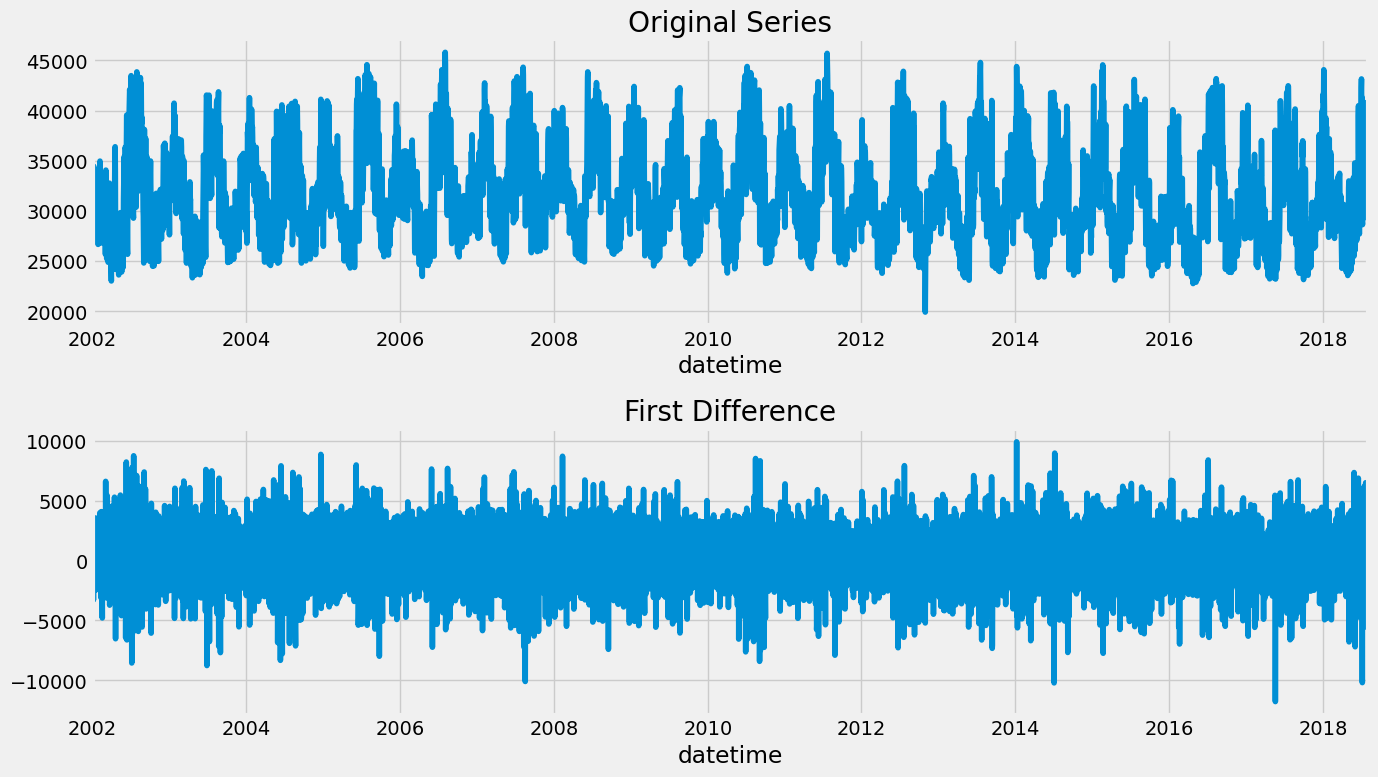

In [2]:
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'--- {title} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Stationary: {"Yes" if result[1] < 0.05 else "No"}')
    print()

adf_test(df_daily['energy_mw'], 'Original Series')

df_daily['diff_1'] = df_daily['energy_mw'].diff()
adf_test(df_daily['diff_1'], 'First Difference (d=1)')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
df_daily['energy_mw'].plot(ax=axes[0], title='Original Series')
df_daily['diff_1'].plot(ax=axes[1], title='First Difference')
plt.tight_layout()
plt.show()

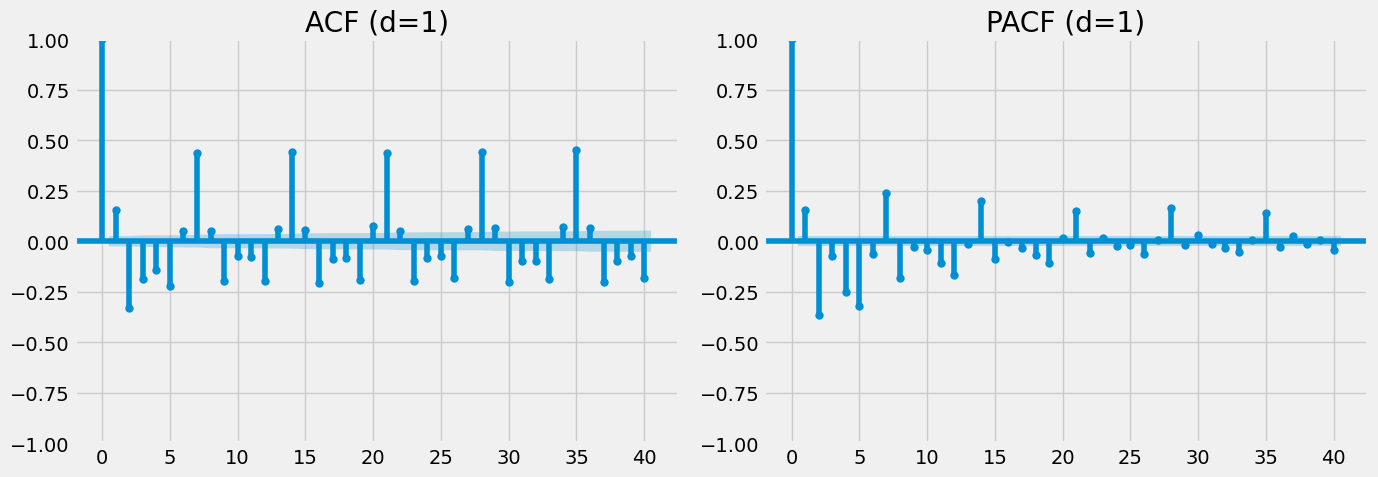

PACF → significant lags suggest p value
ACF  → significant lags suggest q value


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df_daily['diff_1'].dropna(), lags=40, ax=axes[0], title='ACF (d=1)')
plot_pacf(df_daily['diff_1'].dropna(), lags=40, ax=axes[1], title='PACF (d=1)')
plt.tight_layout()
plt.show()

print("PACF → significant lags suggest p value")
print("ACF  → significant lags suggest q value")

In [4]:
split_date = '2018-01-01'
train = df_daily[df_daily.index < split_date]['energy_mw']
test = df_daily[df_daily.index >= split_date]['energy_mw']

print(f"Train: {len(train)} days")
print(f"Test: {len(test)} days")

Train: 5844 days
Test: 215 days


In [5]:
from itertools import product

p_range = range(0, 4)
d_range = [1]
q_range = range(0, 4)

best_aic = float('inf')
best_order = None
results = []

total = len(list(product(p_range, d_range, q_range)))
print(f"Testing {total} combinations...\n")

for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        results.append({'order': (p, d, q), 'AIC': fitted.aic})
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            print(f"  New best: ARIMA{(p,d,q)} | AIC: {fitted.aic:.2f}")
    except:
        continue

print(f"\nBest order: ARIMA{best_order} | AIC: {best_aic:.2f}")

Testing 16 combinations...

  New best: ARIMA(0, 1, 0) | AIC: 107404.26
  New best: ARIMA(0, 1, 1) | AIC: 107048.05
  New best: ARIMA(0, 1, 2) | AIC: 106221.33
  New best: ARIMA(0, 1, 3) | AIC: 105880.88
  New best: ARIMA(1, 1, 2) | AIC: 105879.13
  New best: ARIMA(1, 1, 3) | AIC: 105865.71
  New best: ARIMA(2, 1, 2) | AIC: 105832.52
  New best: ARIMA(2, 1, 3) | AIC: 105803.01
  New best: ARIMA(3, 1, 2) | AIC: 105798.90
  New best: ARIMA(3, 1, 3) | AIC: 105779.46

Best order: ARIMA(3, 1, 3) | AIC: 105779.46


In [6]:
model = ARIMA(train, order=best_order)
fitted = model.fit()

print(fitted.summary())

                               SARIMAX Results                                
Dep. Variable:              energy_mw   No. Observations:                 5844
Model:                 ARIMA(3, 1, 3)   Log Likelihood              -52882.730
Date:                Tue, 10 Mar 2026   AIC                         105779.460
Time:                        11:03:29   BIC                         105826.171
Sample:                    01-01-2002   HQIC                        105795.703
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4776      0.100      4.767      0.000       0.281       0.674
ar.L2          0.0536      0.058      0.927      0.354      -0.060       0.167
ar.L3         -0.2498      0.029     -8.567      0.0

MAE:  5837.35 MW
RMSE: 6654.22 MW
MAPE: 19.99%


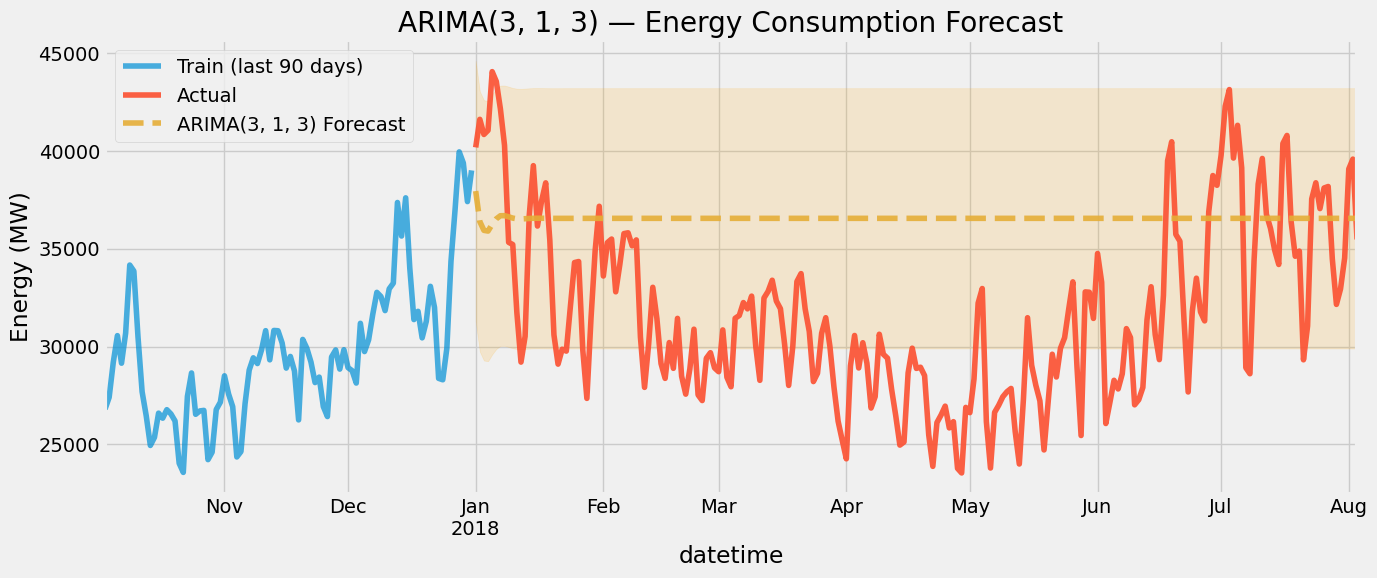

In [7]:
forecast = fitted.forecast(steps=len(test))
forecast.index = test.index

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(14, 6))
train[-90:].plot(ax=ax, label='Train (last 90 days)', alpha=0.7)
test.plot(ax=ax, label='Actual', alpha=0.9)
forecast.plot(ax=ax, label=f'ARIMA{best_order} Forecast', linestyle='--', alpha=0.9)
ax.fill_between(test.index, forecast - rmse, forecast + rmse, alpha=0.15, color='orange')
ax.set_title(f'ARIMA{best_order} — Energy Consumption Forecast')
ax.set_ylabel('Energy (MW)')
ax.legend()
plt.tight_layout()
plt.show()

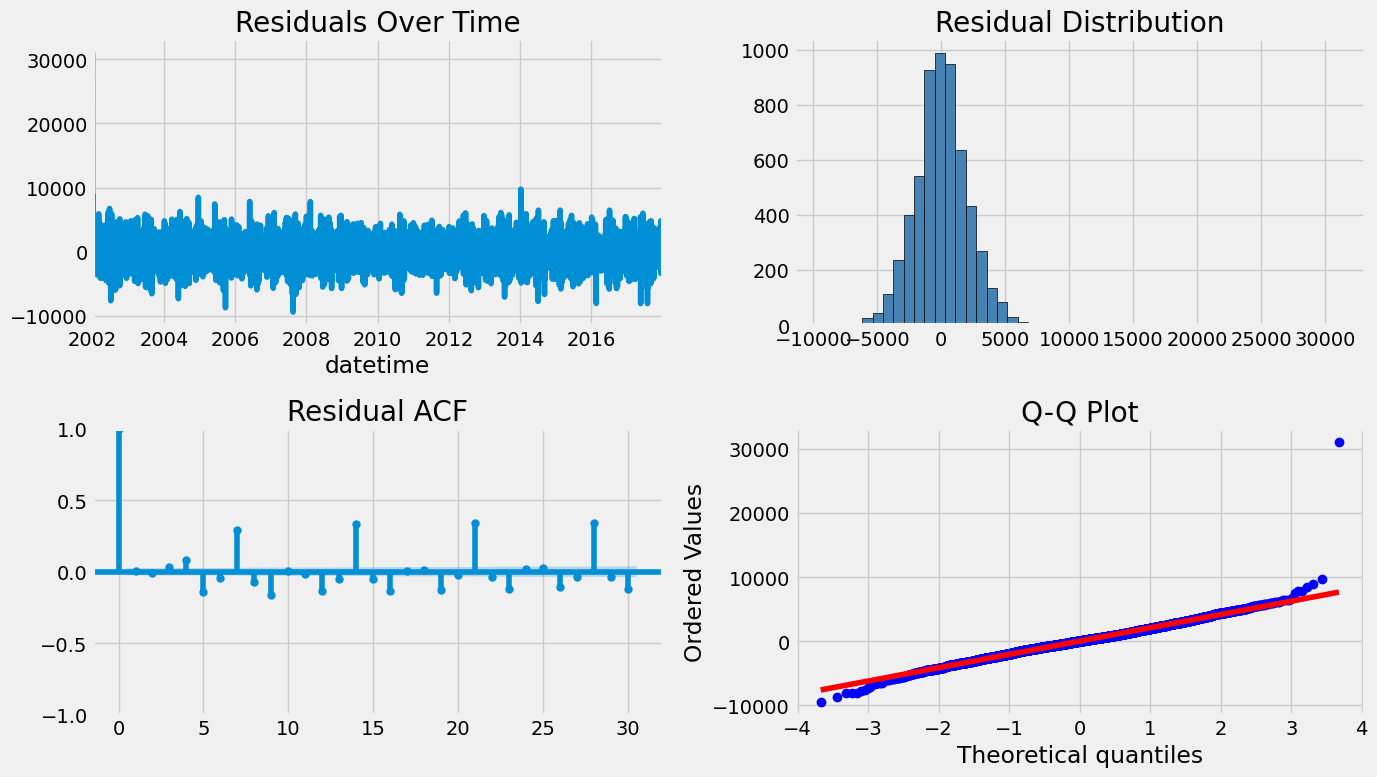

Residual mean: 12.5473
Residual std: 2101.4283


In [8]:
residuals = fitted.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residuals.plot(ax=axes[0, 0], title='Residuals Over Time')
residuals.hist(bins=50, ax=axes[0, 1], color='steelblue', edgecolor='black')
axes[0, 1].set_title('Residual Distribution')
plot_acf(residuals, lags=30, ax=axes[1, 0], title='Residual ACF')
from scipy import stats
stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std: {residuals.std():.4f}")

In [10]:
results_df = pd.DataFrame({
    'actual': test,
    'predicted': forecast
})
results_df.to_csv('../results/arima_results.csv')

metrics = {
    'model': f'ARIMA{best_order}',
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape
}
pd.DataFrame([metrics]).to_csv('../results/arima_metrics.csv', index=False)

print("Saved to results/")

Saved to results/
